<a href="https://colab.research.google.com/github/gaurav-0022/Assignment-1/blob/main/Logistic_Regression_(Loan_Approval_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Q1. Data Loading & Understanding

a) Load the dataset into Python.

b) Display the first 5 rows.

c) Check the shape of the dataset.

d) Display the data types of each column

In [14]:
import pandas as pd
from google.colab import files

In [16]:
uploaded = files.upload()

Saving loan_approval.csv to loan_approval.csv


In [20]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [21]:
print("Shape:", df.shape)

Shape: (2000, 8)


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


##Q2. Data Cleaning

a) Check for missing values in the dataset.

b) Handle missing values appropriately.

c) Identify categorical columns present in the dataset.

In [23]:
# a) Missing values
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [27]:
# b) Handle missing values
# Numerical columns → fill with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [26]:
# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_624/1867403142.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [28]:
# c) Identify categorical columns
print("Categorical Columns:", cat_cols)

Categorical Columns: Index(['name', 'city'], dtype='object')


##Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.

b) Analyze the relationship between one numerical feature and the target variable.

c) Analyze the relationship between Years of Employment and the target variable.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns


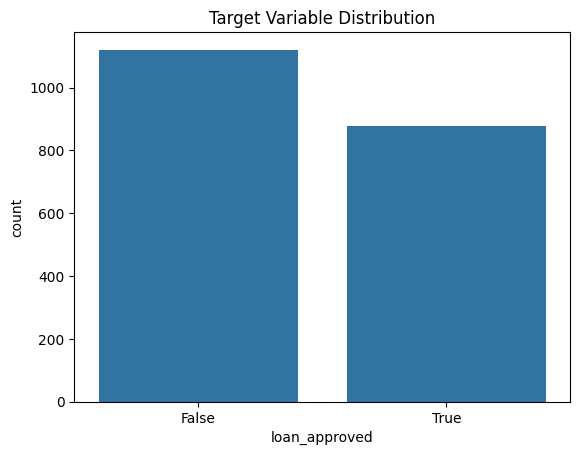

In [31]:
# a) Target distribution
sns.countplot(x='loan_approved', data=df)
plt.title("Target Variable Distribution")
plt.show()

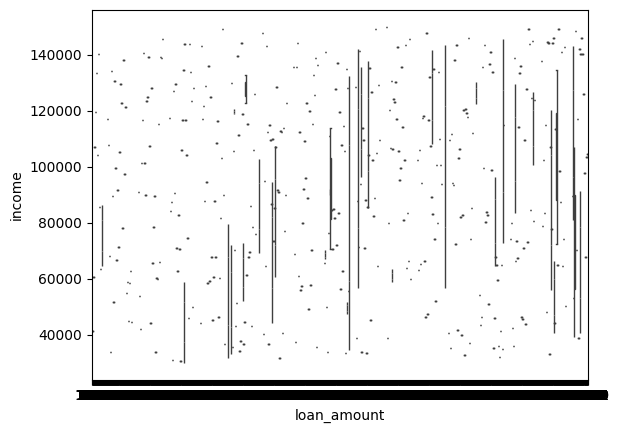

In [36]:

# b) Numerical feature vs target
sns.boxplot(x='loan_amount', y='income', data=df)
plt.show()

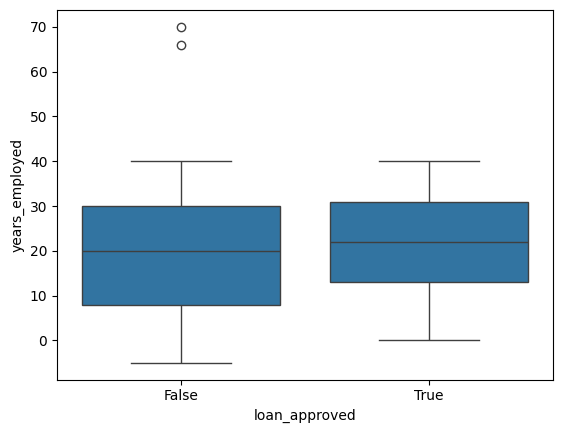

In [38]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.show()

##Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.

b) Treat outliers using capping techniques

In [54]:
# Function for outlier capping
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)

In [41]:
# Apply to numerical columns
for col in num_cols:
    cap_outliers(col)

##Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
columns.

In [55]:
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

In [45]:
# Convert target variable if needed
# Example: Yes/No → 1/0
if df['loan_approved'].dtype == 'object':
    df['loan_approved'] = df['loan_approved'].map({'Y':1, 'N':0})

In [46]:
# Drop unnecessary columns (example)
df.drop(columns=['Loan_ID'], inplace=True, errors='ignore')

##Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y)

b) Split the dataset into training and testing sets.

In [60]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

In [62]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

##Q7. Apply feature scaling to the dataset using StandardScaler.

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Q8. Logistic Regression Model Building

a) Train a Logistic Regression model.

b) Predict the output for test data.

In [64]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [65]:
# Predictions
y_pred = model.predict(X_test)

##Q9. Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.

b) Interpret the results.

In [69]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[214   3]
 [ 39 144]]

Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.99      0.91       217
        True       0.98      0.79      0.87       183

    accuracy                           0.90       400
   macro avg       0.91      0.89      0.89       400
weighted avg       0.91      0.90      0.89       400



##Q10. Model Evaluation – ROC Curve & AUC

a) Plot the ROC curve.

b) Calculate the AUC score.

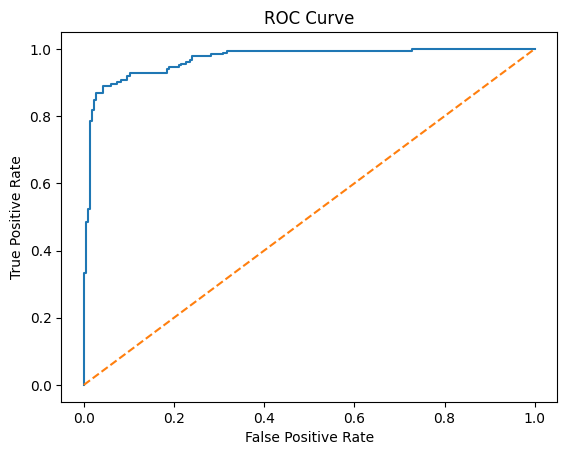

In [70]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()